In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import json
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers,Model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import MobileNetV2,ResNet50V2,EfficientNetB0
data,info=tfds.load('plant_village',split='train',with_info=True,as_supervised=True)

In [2]:
data_size=info.splits["train"].num_examples
class_names=info.features["label"].names
n_classes=info.features["label"].num_classes
print("data size :",data_size,"\nclass_names:",class_names,"\n classes :",n_classes)
print("GPU: ",len(tf.config.list_physical_devices("GPU")))

data size : 54303 
class_names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___

In [3]:
for image, label in data.take(1):
    print('Image shape:', image.shape)
    print('Label:', label.numpy())

I0000 00:00:1782820961.154502   33043 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Image shape: (256, 256, 3)
Label: 35


In [4]:
train_data=data.take(round(0.8*data_size))
test_data=data.skip(round(0.8*data_size))

In [5]:
AUTOTUNE = tf.data.AUTOTUNE
def get_dataset(model_name,train_data,test_data,eva=False):
    models={'MobileNetV2': tf.keras.applications.mobilenet_v2.preprocess_input,
        'ResNet50':tf.keras.applications.resnet50.preprocess_input,
        'EfficientNetB0':tf.keras.applications.efficientnet.preprocess_input}
    preprocess_input=models[model_name]
    
    def preprocess(image,label):
        image=tf.image.resize(image,(160,160)) #image size are equal for all models for fair comparision
        image=tf.cast(image,tf.float32) 
        image = preprocess_input(image)
        label=tf.one_hot(label,depth=38)
        return image,label
    augumentation=tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(.2),
        layers.RandomZoom(.2)
    ])
    
    train_p_data=train_data.map(preprocess, tf.data.AUTOTUNE).map(lambda image,label:(augumentation(image,training=True),label),
                                num_parallel_calls=AUTOTUNE).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
    test_p_data=test_data.map(preprocess, tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
    return train_p_data,test_p_data
    

In [6]:
def build_model(model_backbone,train_base=False):
    backbone={'MobileNetV2': tf.keras.applications.MobileNetV2,       
        'ResNet50': tf.keras.applications.ResNet50,               
        'EfficientNetB0': tf.keras.applications.EfficientNetB0}
    base=backbone[model_backbone](input_shape=(160,160,3),include_top=False,weights="imagenet")

    base.trainable=train_base
    inputs=tf.keras.Input(shape=(160,160,3))
    x=base(inputs,training=False)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dense(256,activation='relu')(x)
    x=layers.Dropout(.2)(x)
    outputs=layers.Dense(38,activation='softmax')(x)
    return Model(inputs,outputs),base
callback=EarlyStopping(
    monitor='val_loss',   
    patience=2,           
    restore_best_weights=True  
)

**MobileNetV2**

In [7]:
train_p_data,test_p_data=get_dataset('MobileNetV2',train_data,test_data)
model1,base1=build_model('MobileNetV2')
model1.compile(optimizer=tf.keras.optimizers.Adam(.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary() 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
for image, label in train_p_data.take(1):
    print("Image min:", tf.reduce_min(image).numpy())
    print("Image max:", tf.reduce_max(image).numpy())

Image min: -1.0
Image max: 0.9760925


In [9]:
history1 = model1.fit(
    train_p_data,
    validation_data=test_p_data,
    epochs=10,callbacks=callback)

Epoch 1/10


W0000 00:00:1782820978.529753   33220 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782820978.605794   33026 service.cc:153] XLA service 0x706424069070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782820978.606066   33026 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782820979.189924   33026 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782820981.955567   33026 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782820982.142889   33026 dot_merger.cc:481] Merging Dots in computation: a_inf

1356/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5606 - loss: 1.7520

I0000 00:00:1782821202.700894   33027 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8452__.123
I0000 00:00:1782821204.877294   33027 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5608 - loss: 1.7509

...

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 101ms/step - accuracy: 0.8758 - loss: 0.4151 - val_accuracy: 0.8889 - val_loss: 0.3548
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 137s 99ms/step - accuracy: 0.9021 - loss: 0.3160 - val_accuracy: 0.9034 - val_loss: 0.2982
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9124 - loss: 0.2782

W0000 00:00:1782821657.786226   35007 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16782080 bytes after encountering the first element of size 16782080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - accuracy: 0.9140 - loss: 0.2700 - val_accuracy: 0.9105 - val_loss: 0.2740
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9228 - loss: 0.2441

W0000 00:00:1782821774.238461   35007 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16782080 bytes after encountering the first element of size 16782080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 117s 85ms/step - accuracy: 0.9226 - loss: 0.2425 - val_accuracy: 0.9133 - val_loss: 0.2597
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 115s 83ms/step - accuracy: 0.9285 - loss: 0.2211 - val_accuracy: 0.9240 - val_loss: 0.2318
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 122s 89ms/step - accuracy: 0.9323 - loss: 0.2110 - val_accuracy: 0.9279 - val_loss: 0.2162
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 121s 88ms/step - accuracy: 0.9372 - loss: 0.1916 - val_accuracy: 0.9260 - val_loss: 0.2201
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 134s 97ms/step - accuracy: 0.9397 - loss: 0.1843 - val_accuracy: 0.9290 - val_loss: 0.2102
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 125s 91ms/step - accuracy: 0.9419 - loss: 0.1760 - val_accuracy: 0.9341 - val_loss: 0.1990


In [10]:
base1.trainable=True
total_layers=len(base1.layers)
freeze_until=int(total_layers *(1-.30)) 

for layer in base1.layers[:freeze_until]:
    layer.trainable=False
model1.compile(
    optimizer=tf.keras.optimizers.Adam(.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
history1=model1.fit(train_p_data,epochs=5,validation_data=test_p_data,callbacks=callback)

Epoch 1/5


I0000 00:00:1782822421.050298   33026 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98079__.187


1356/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7978 - loss: 0.6776

I0000 00:00:1782822565.200487   33026 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98079__.187


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 202s 119ms/step - accuracy: 0.8694 - loss: 0.4217 - val_accuracy: 0.9226 - val_loss: 0.2253
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 134s 97ms/step - accuracy: 0.9300 - loss: 0.2128 - val_accuracy: 0.9459 - val_loss: 0.1638
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 94ms/step - accuracy: 0.9456 - loss: 0.1656 - val_accuracy: 0.9525 - val_loss: 0.1379
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 128s 93ms/step - accuracy: 0.9534 - loss: 0.1398 - val_accuracy: 0.9564 - val_loss: 0.1312
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9573 - loss: 0.1270

W0000 00:00:1782823114.054314   40498 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16782080 bytes after encountering the first element of size 16782080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 94ms/step - accuracy: 0.9596 - loss: 0.1221 - val_accuracy: 0.9618 - val_loss: 0.1119


In [50]:
result={}
# model1_test_loss,model1_test_accuracy=model1.evaluate(test_p_data)
result["MobileNetV2"]={"train accuracy":round(max(history1.history["accuracy"]),2),
                       "train loss":round(min(history1.history["loss"]),2),
                       "validation accuracy":round(max(history1.history["val_accuracy"]),2),
                       "validation loss":round(min(history1.history["val_loss"]),2),
                       "Evaluation accuracy":round(model1_test_accuracy,2),
                       "Evaluation loss":round(model1_test_loss,2)}
print(result)

{'MobileNetV2': {'train accuracy': 0.96, 'train loss': 0.12, 'validation accuracy': 0.96, 'validation loss': 0.12, 'Evaluation accuracy': 0.96, 'Evaluation loss': 0.12}}


**2.ResNet50**

In [13]:
train_p_data,test_p_data=get_dataset("ResNet50",train_data,test_data)
model2,base2=build_model('ResNet50')
model2.compile(optimizer=tf.keras.optimizers.Adam(.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary() 

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,022 (92.02 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
for image, label in train_p_data.take(1):
    print("Image min:", tf.reduce_min(image).numpy())
    print("Image max:", tf.reduce_max(image).numpy())

W0000 00:00:1782814731.913530    2254 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Image min: -122.42485
Image max: 150.9135


In [15]:
history2 = model2.fit(
    train_p_data,
    validation_data=test_p_data,
    epochs=10,callbacks=callback)

Epoch 1/10


I0000 00:00:1782814757.454602    2332 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_150301__.186


1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6129 - loss: 1.5338

I0000 00:00:1782814974.365173    2334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_150301__.186


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 303s 196ms/step - accuracy: 0.7614 - loss: 0.9031 - val_accuracy: 0.8902 - val_loss: 0.3679
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9032 - loss: 0.3274 - val_accuracy: 0.9180 - val_loss: 0.2628


In [16]:
base2.trainable=True
total_layers=len(base2.layers)
freeze_until=int(total_layers *(1-.30)) 

for layer in base2.layers[:freeze_until]:
    layer.trainable=False
model2.compile(
    optimizer=tf.keras.optimizers.Adam(.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
inal_history2=model2.fit(train_p_data,epochs=5,validation_data=test_p_data,verbose=1,callbacks=callback)

Epoch 1/5


I0000 00:00:1782815290.990579    2335 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_186547__.250
W0000 00:00:1782815305.391514    2335 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.25GiB (rounded to 2417558016)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1782815305.397701    2335 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1782815305.397709    2335 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 223, Chunks in use: 221. 55.8KiB allocated for chunks. 55.2KiB in use in bin. 18.3KiB client-requested in use in bin.
I0000 00:00:1782815305.397715    2335 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 123, Chunks in use: 122. 76.8KiB allocated for chunks. 76.0KiB in use in bin. 67.2KiB client-requested in use in b

1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8398 - loss: 0.5518

I0000 00:00:1782815572.613422    2335 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_186547__.250
W0000 00:00:1782815584.624201    2335 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.25GiB (rounded to 2419606016)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1782815584.624725    2335 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1782815584.624730    2335 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 230, Chunks in use: 229. 57.5KiB allocated for chunks. 57.2KiB in use in bin. 18.5KiB client-requested in use in bin.
I0000 00:00:1782815584.624736    2335 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 123, Chunks in use: 122. 76.5KiB allocated for chunks. 76.0KiB in use in bin. 67.2KiB client-requested in use in b

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 398s 242ms/step - accuracy: 0.8923 - loss: 0.3620 - val_accuracy: 0.9365 - val_loss: 0.1979
Epoch 2/5


W0000 00:00:1782815663.854848   15545 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 269s 195ms/step - accuracy: 0.9497 - loss: 0.1592 - val_accuracy: 0.9623 - val_loss: 0.1169
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 269s 196ms/step - accuracy: 0.9661 - loss: 0.1060 - val_accuracy: 0.9715 - val_loss: 0.0863
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 273s 200ms/step - accuracy: 0.9749 - loss: 0.0785 - val_accuracy: 0.9743 - val_loss: 0.0809
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9788 - loss: 0.0636

W0000 00:00:1782816717.376521   17126 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16782080 bytes after encountering the first element of size 16782080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 272s 197ms/step - accuracy: 0.9801 - loss: 0.0606 - val_accuracy: 0.9795 - val_loss: 0.0645


In [51]:
# model2_test_loss,model2_test_accuracy=model2.evaluate(test_p_data)
result["ResNet"]={"train accuracy":round(max(history2.history["accuracy"]),2),
                       "train loss":round(min(history2.history["loss"]),2),
                       "validation accuracy":round(max(history2.history["val_accuracy"]),2),
                       "validation loss":round(min(history2.history["val_loss"]),2),
                       "Evaluation accuracy":round(model2_test_accuracy,2),
                       "Evaluation loss":round(model2_test_loss,2)}

print(result)

{'MobileNetV2': {'train accuracy': 0.96, 'train loss': 0.12, 'validation accuracy': 0.96, 'validation loss': 0.12, 'Evaluation accuracy': 0.96, 'Evaluation loss': 0.12}, 'ResNet': {'train accuracy': 0.9, 'train loss': 0.33, 'validation accuracy': 0.92, 'validation loss': 0.26, 'Evaluation accuracy': 0.62, 'Evaluation loss': 1.76}}


**EfficientNetB0**

In [18]:
train_p_data,test_p_data=get_dataset("EfficientNetB0",train_data,test_data)
model3,base3=build_model('EfficientNetB0')
model3.compile(optimizer=tf.keras.optimizers.Adam(.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model3.summary() 

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,387,273 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
for image, label in train_p_data.take(1):
    print("Image min:", tf.reduce_min(image).numpy())
    print("Image max:", tf.reduce_max(image).numpy())

W0000 00:00:1782816836.670778    2254 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Image min: 0.0
Image max: 237.48749


In [21]:
history3 = model3.fit(
    train_p_data,
    validation_data=test_p_data,
    epochs=10,verbose=0,callbacks=callback)

I0000 00:00:1782816958.714677    2332 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245423__.255
E0000 00:00:1782816968.623711    2332 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1782817093.074210    2334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245423__.255
E0000 00:00:1782817109.421398    2334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0000 00:00:1782817180.521105   20845 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


In [22]:
base3.trainable=True
total_layers=len(base3.layers)
freeze_until=int(total_layers *(1-.30)) 

for layer in base3.layers[:freeze_until]:
    layer.trainable=False
model3.compile(
    optimizer=tf.keras.optimizers.Adam(.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
history3=model3.fit(train_p_data,epochs=5,validation_data=test_p_data,callbacks=callback,verbose=1)

Epoch 1/5


W0000 00:00:1782817344.978319   23907 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9835264 bytes after encountering the first element of size 9835264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782817354.584639    2333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_287018__.315


1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7086 - loss: 1.3845

I0000 00:00:1782817534.222765    2334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_287018__.315


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 282s 156ms/step - accuracy: 0.7772 - loss: 0.9872 - val_accuracy: 0.8789 - val_loss: 0.4464
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8632 - loss: 0.4941

W0000 00:00:1782817733.874801   25291 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16782080 bytes after encountering the first element of size 16782080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 153s 110ms/step - accuracy: 0.8765 - loss: 0.4401 - val_accuracy: 0.9164 - val_loss: 0.2760


In [52]:
# model3_test_loss,model3_test_accuracy=model3.evaluate(test_p_data)
result["EfficientNetB0"]={"train accuracy":round(max(history3.history["accuracy"]),2),
                       "train loss":round(min(history3.history["loss"]),2),
                       "validation accuracy":round(max(history3.history["val_accuracy"]),2),
                       "validation loss":round(min(history3.history["val_loss"]),2),
                       "Evaluation accuracy":round(model3_test_accuracy,2),
                       "Evaluation loss":round(model3_test_loss,2)}
print(result )

{'MobileNetV2': {'train accuracy': 0.96, 'train loss': 0.12, 'validation accuracy': 0.96, 'validation loss': 0.12, 'Evaluation accuracy': 0.96, 'Evaluation loss': 0.12}, 'ResNet': {'train accuracy': 0.9, 'train loss': 0.33, 'validation accuracy': 0.92, 'validation loss': 0.26, 'Evaluation accuracy': 0.62, 'Evaluation loss': 1.76}, 'EfficientNetB0': {'train accuracy': 0.88, 'train loss': 0.44, 'validation accuracy': 0.92, 'validation loss': 0.28, 'Evaluation accuracy': 0.88, 'Evaluation loss': 0.45}}


In [24]:
print(result)

{'MobileNetV2': {'train accuracy': 95.83, 'train loss': 0.12, 'validation accuracy': 95.95, 'validation loss': 0.12, 'Evaluation accuracy': 0.9594880938529968, 'Evaluavation loss': 0.11826310306787491}, 'EfficientNetB0': {'train accuracy': 87.65, 'train loss': 0.44, 'validation accuracy': 91.64, 'validation loss': 0.28, 'Evaluation accuracy': 0.8789246082305908, 'Evaluation loss': 0.44641733169555664}}


                train accuracy  train loss  validation accuracy  \
MobileNetV2               0.96        0.12                 0.96   
ResNet                    0.90        0.33                 0.92   
EfficientNetB0            0.88        0.44                 0.92   

                validation loss  Evaluation accuracy  Evaluation loss  
MobileNetV2                0.12                 0.96             0.12  
ResNet                     0.26                 0.62             1.76  
EfficientNetB0             0.28                 0.88             0.45  


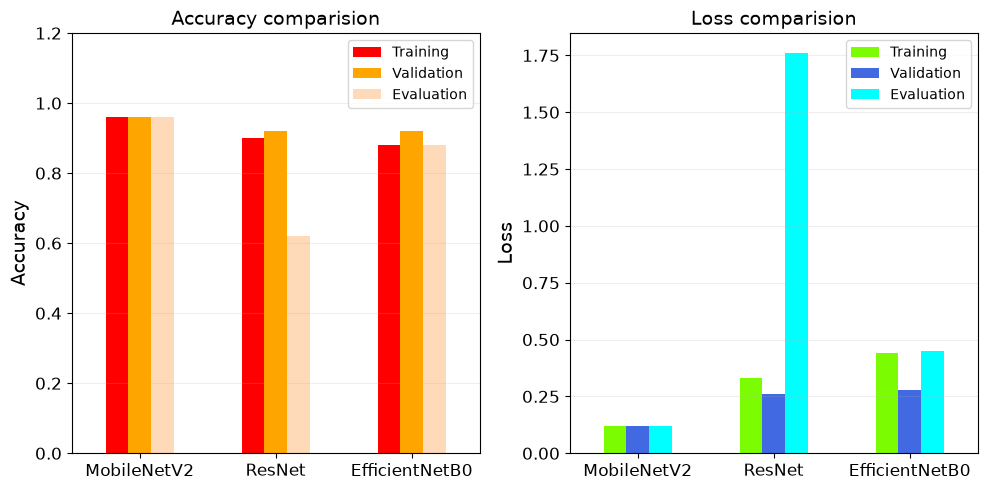

In [70]:
df=pd.DataFrame(result).T
fig,axes=plt.subplots(1,2,figsize=(10,5))
print(df)
df[["train accuracy","validation accuracy","Evaluation accuracy"]].plot(kind='bar',ax=axes[0],fontsize=12,color=['red','orange','peachpuff'])
axes[0].set_title("Accuracy comparision",fontsize=14)
axes[0].set_ylabel("Accuracy",fontsize=14)
axes[0].set_ylim([0,1.2])
axes[0].grid(axis='y',alpha=.2)
axes[0].legend(["Training","Validation","Evaluation"],loc="upper right")

df[["train loss","validation loss","Evaluation loss"]].plot(kind='bar',ax=axes[1],fontsize=12,color=['lawngreen','royalblue','cyan'])
axes[1].set_title("Loss comparision",fontsize=14)
axes[1].set_ylabel("Loss",fontsize=14)
axes[1].grid(axis='y',alpha=.2)
axes[1].legend(["Training","Validation","Evaluation"],loc="upper right")
axes[1].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig("Images/comparision.png")
plt.show()  

From this, we can say that, "MobileNetV2" model performs better compare to others.

In [13]:
model1.save("models/MobileNet.keras")
with open('models/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)